# Dimensionless Cross-Field Diffusion in the Souza Tokamak Escape Map

**Maximus Cullan — 2026**

This notebook contains the Python implementation used for the numerical
simulations, verification tests, and figures presented in the accompanying
research report.

Included is the deterministic Souza map, the existing Souza
stochastic treatment used as a reference, and the dimensionless cross-field
diffusion model developed in this project.

The internal Python variable `Db` corresponds to the dimensionless diffusion
strength $\hat{D}$ used in the report.

`RUN_MODE = "final"` reproduces the numerical settings used for the reported
results. The `"development"` mode uses reduced settings for faster testing.

In [46]:
### Imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from numba import njit, prange
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

In [47]:
### Model Constants

# ------------------------------------------------------------
# Souza-map constants
# ------------------------------------------------------------

M = 15
L = 6
OMEGA = 16.36

A0 = 0.18
R0 = 0.615


# ------------------------------------------------------------
# Primary perturbation amplitude
# ------------------------------------------------------------

PHI_PRIMARY = 8.74e-3


# ------------------------------------------------------------
# Primary edge-region initial-condition domain
# ------------------------------------------------------------

I_EDGE_MIN = 0.80
I_EDGE_MAX = 0.99

PSI_NORM_MIN = -0.5
PSI_NORM_MAX = 0.5


# ------------------------------------------------------------
# New diffusion-model validity limit
# ------------------------------------------------------------

I_VALID_MIN = 0.20


# ------------------------------------------------------------
# Ambiguity definition
# ------------------------------------------------------------

AMBIGUITY_THRESHOLD = 0.10
MIN_ESCAPED_FRACTION = 0.90

# Minimum number of ambiguous samples required before
# plotting/reporting a 90th-percentile width.
MIN_AMBIGUOUS_SAMPLES = 10


# ------------------------------------------------------------
# Required Db scan
# ------------------------------------------------------------

DB_SCAN = np.array([
    0.0,
    1e-6,
    3e-6,
    1e-5,
    3e-5,
    1e-4,
    3e-4,
    1e-3
], dtype=np.float64)


# ------------------------------------------------------------
# Existing Souza-noise control
# ------------------------------------------------------------

SOUZA_RHO_CONTROL = 1e-3
SOUZA_P_CONTROL = 1.0


# ------------------------------------------------------------
# Random-number seeds
# ------------------------------------------------------------

MASTER_SEED = 12345

# Separate deterministic seed streams for different tasks
INITIAL_CONDITION_SEED = MASTER_SEED
GRID_NOISE_SEED = MASTER_SEED + 100000
GLOBAL_NOISE_SEED = MASTER_SEED + 200000
CONVERGENCE_NOISE_SEED = MASTER_SEED + 300000
SOUZA_NOISE_SEED = MASTER_SEED + 400000

In [48]:
### Numerical Settings

RUN_MODE = "final"

if RUN_MODE == "development":

    N_I = 30
    N_PSI = 60

    RMC_GRID = 16
    NC = 8
    NMAX = 5000

    N_GLOBAL = 300
    RMC_GLOBAL = 16

elif RUN_MODE == "final":

    N_I = 60
    N_PSI = 120

    RMC_GRID = 64
    NC = 32
    NMAX = 20000

    N_GLOBAL = 1000
    RMC_GLOBAL = 64

else:

    raise ValueError(
        "RUN_MODE must be either 'development' or 'final'."
    )


print("Run mode:", RUN_MODE)
print("Grid:", N_I, "x", N_PSI)
print("Grid Monte Carlo repetitions:", RMC_GRID)
print("Nc:", NC)
print("nmax:", NMAX)

Run mode: final
Grid: 60 x 120
Grid Monte Carlo repetitions: 64
Nc: 32
nmax: 20000


In [49]:
### Ambiguity Helper

def calculate_ambiguity_metrics(
    qeL,
    qeR,
    escaped_fraction,
    distance_grid,
    threshold=AMBIGUITY_THRESHOLD,
    min_escaped=MIN_ESCAPED_FRACTION
):
    """
    Construct the stochastic ambiguity set and calculate
    the 90th-percentile distance from the deterministic
    basin boundary.
    """

    mask = (
        np.isfinite(qeL)
        & np.isfinite(qeR)
        & (qeL >= threshold)
        & (qeR >= threshold)
        & (escaped_fraction >= min_escaped)
    )

    distances = distance_grid[mask]

    if distances.size > 0:

        width = np.percentile(
            distances,
            90
        )

    else:

        width = np.nan

    return mask, distances, width

In [50]:
### Outcome Summary Helper

def summarize_outcomes(
    outcomes,
    iterations
):
    """
    Calculate global L/R/S/V probabilities and
    the median escape iteration among physical exits.
    """

    PL = np.mean(outcomes == 0)
    PR = np.mean(outcomes == 1)
    PS = np.mean(outcomes == 2)
    PV = np.mean(outcomes == 3)

    escaped_mask = (
        (outcomes == 0)
        | (outcomes == 1)
    )

    escaped_iterations = iterations[
        escaped_mask
    ]

    if escaped_iterations.size > 0:

        median_escape_iteration = np.median(
            escaped_iterations
        )

    else:

        median_escape_iteration = np.nan

    return (
        PL,
        PR,
        PS,
        PV,
        median_escape_iteration
    )

In [51]:
### Physical/Profile Functions

@njit
def v_parallel(I):
    """
    Parallel velocity profile.
    """
    return (
        -9.867
        + 17.47 * np.tanh(10.1 * I - 9.00)
    )


@njit
def q_safety(I):
    """
    Safety factor q(I).
    """
    return (
        5.0
        - 6.3 * I**2
        + 6.3 * I**3
    )


@njit
def E_r_bar(I):
    """
    Normalised radial electric field.
    """
    return (
        10.7 * I
        - 15.8 * np.sqrt(I)
        + 4.13
    )


@njit
def F(I):
    """
    Deterministic Souza phase drift F(I).
    """

    q_val = q_safety(I)

    return (
        (
            2.0
            * np.pi
            * A0
            * v_parallel(I)
            / (OMEGA * R0)
        )
        * (
            (M - L * q_val)
            / q_val
        )
        - (
            2.0
            * np.pi
            * M
            / OMEGA
        )
        * E_r_bar(I)
        / np.sqrt(I)
    )


@njit
def wrap_angle(psi):
    """
    Wrap phase into the principal interval.
    """
    return np.arctan2(
        np.sin(psi),
        np.cos(psi)
    )

In [52]:
### Original Souza Phenomenological Noise

@njit
def set_numba_seed(seed):
    """
    Explicitly seed Numba's random-number generator.
    """
    np.random.seed(seed)


@njit
def fixed_stochastic_collision(
    I,
    psi,
    rho,
    P
):
    """
    Original Souza-style phenomenological random kick.

    With probability P, apply a fixed-amplitude
    perturbation rho in a random direction.
    """

    if np.random.random() < P:

        Gamma = np.random.uniform(
            -np.pi,
            np.pi
        )

        I += rho * np.sin(Gamma)
        psi += rho * np.cos(Gamma)

    return I, psi

In [53]:
### Original Souza Map Iterator

@njit
def iterate_map(
    I0,
    psi0,
    phi,
    N_steps,
    collision_model=0,
    collision_amplitude=0.0,
    collision_probability=0.0
):
    """
    Iterate the original Souza map.

    collision_model:
        0 = deterministic / collisionless
        1 = original Souza phenomenological noise
    """

    K = (
        4.0
        * np.pi
        * M
        * phi
        / OMEGA
    )

    I_values = np.empty(
        N_steps,
        dtype=np.float64
    )

    psi_values = np.empty(
        N_steps,
        dtype=np.float64
    )

    I = I0
    psi = psi0

    for n in range(N_steps):

        # ----------------------------------------------------
        # Deterministic Souza radial kick
        # ----------------------------------------------------

        I_next = (
            I
            + K * np.sin(psi)
        )

        # Numerical protection retained from original baseline
        if I_next < 1e-8:
            I_next = 1e-8

        # ----------------------------------------------------
        # Deterministic phase update
        # ----------------------------------------------------

        psi_next = (
            psi
            + F(I_next)
        )

        # ----------------------------------------------------
        # Optional original Souza phenomenological noise
        # ----------------------------------------------------

        if collision_model == 1:

            I_next, psi_next = (
                fixed_stochastic_collision(
                    I_next,
                    psi_next,
                    collision_amplitude,
                    collision_probability
                )
            )

        elif collision_model != 0:

            raise ValueError(
                "collision_model must be 0 or 1."
            )

        I_values[n] = I_next
        psi_values[n] = wrap_angle(
            psi_next
        )

        I = I_next
        psi = psi_next

    return I_values, psi_values

In [54]:
### Poincare Phase-Space Generator

def generate_phase_space(
    phi=PHI_PRIMARY,
    N_steps=700,
    num_initial_I=25,
    num_initial_psi=25,
    I_min=0.30,
    I_max=1.00,
    psi_min=-np.pi,
    psi_max=np.pi,
    collision_model=0,
    collision_amplitude=0.0,
    collision_probability=0.0,
    burn_in=50
):
    """
    Generate a Poincare-style phase-space data set.

    The first `burn_in` map periods are removed from
    each trajectory to reduce transient structure.
    """

    if burn_in < 0 or burn_in >= N_steps:

        raise ValueError(
            "burn_in must satisfy 0 <= burn_in < N_steps."
        )

    I_initials = np.linspace(
        I_min,
        I_max,
        num_initial_I
    )

    psi_initials = np.linspace(
        psi_min,
        psi_max,
        num_initial_psi
    )

    all_I = []
    all_psi = []

    for I0 in I_initials:

        for psi0 in psi_initials:

            I_vals, psi_vals = iterate_map(
                I0,
                psi0,
                phi,
                N_steps,
                collision_model,
                collision_amplitude,
                collision_probability
            )

            all_I.append(
                I_vals[burn_in:]
            )

            all_psi.append(
                psi_vals[burn_in:]
            )

    return (
        np.concatenate(all_I),
        np.concatenate(all_psi)
    )

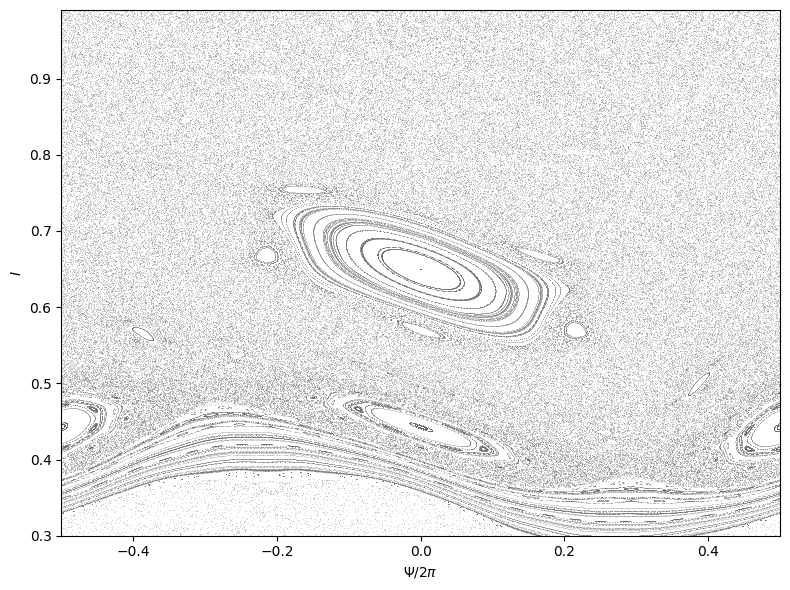

In [55]:
# ============================================================
# Deterministic Poincare section for final report
# ============================================================

phi_poincare = PHI_PRIMARY

I_poincare, psi_poincare = generate_phase_space(
    phi=phi_poincare,
    N_steps=700,
    num_initial_I=25,
    num_initial_psi=25,
    I_min=0.30,
    I_max=1.00,
    psi_min=-np.pi,
    psi_max=np.pi,
    collision_model=0,          # deterministic / collisionless
    collision_amplitude=0.0,
    collision_probability=0.0,
    burn_in=50
)

plt.figure(figsize=(8, 6))

plt.scatter(
    psi_poincare / (2.0 * np.pi),
    I_poincare,
    s=0.18,
    alpha=0.55,
    c="dimgray",
    linewidths=0,
    rasterized=True
)

plt.xlim(-0.5, 0.5)
plt.ylim(0.30, 0.99)

plt.xlabel(r"$\Psi/2\pi$")
plt.ylabel(r"$I$")

plt.tight_layout()

plt.savefig(
    "figure1_deterministic_Poincare_Section.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [56]:
### Deterministic Escape Functions

@njit
def classify_exit(psi):
    """
    Classify an escaped trajectory.

    Returns:
        0 = Left exit
        1 = Right exit
    """

    psi_wrapped = wrap_angle(
        psi
    )

    if psi_wrapped < 0.0:
        return 0

    return 1


@njit
def deterministic_step(
    I,
    psi,
    phi
):
    """
    Perform one complete deterministic Souza map period.
    """

    K = (
        4.0
        * np.pi
        * M
        * phi
        / OMEGA
    )

    # Souza radial kick
    I_next = (
        I
        + K * np.sin(psi)
    )

    # Preserve the exact original numerical baseline
    if I_next < 1e-8:
        I_next = 1e-8

    # Complete deterministic phase update
    psi_next = (
        psi
        + F(I_next)
    )

    return I_next, psi_next


@njit
def deterministic_escape(
    I0,
    psi0,
    phi,
    nmax
):
    """
    Follow one deterministic trajectory until escape
    or until nmax map periods have been completed.

    Returns:
        0 = Left
        1 = Right
        2 = Survival
    """

    I = I0
    psi = psi0

    for n in range(nmax):

        I, psi = deterministic_step(
            I,
            psi,
            phi
        )

        # Escape is checked only after the complete map period
        if I > 1.0:

            return (
                classify_exit(psi),
                n + 1
            )

    return 2, nmax

In [57]:
### Deterministic Basin Generator

@njit(parallel=True)
def generate_deterministic_basin(
    phi,
    I_min,
    I_max,
    n_I,
    psi_norm_min,
    psi_norm_max,
    n_psi,
    nmax
):
    """
    Generate the deterministic two-exit escape basin.

    Basin labels:
        0 = Left exit
        1 = Right exit
        2 = Survival

    Also stores the escape iteration for each initial condition.
    """

    # Create the regular initial-condition grids
    I_grid = np.linspace(I_min, I_max, n_I)

    psi_norm_grid = np.linspace(
        psi_norm_min,
        psi_norm_max,
        n_psi
    )

    # Arrays for the final deterministic outcome
    basin = np.empty(
        (n_I, n_psi),
        dtype=np.int8
    )

    # Array for the iteration on which escape occurs
    escape_iterations = np.empty(
        (n_I, n_psi),
        dtype=np.int32
    )

    # Each initial condition is independent,
    # so different trajectories can be run in parallel
    for index in prange(n_I * n_psi):

        # Convert flattened index into grid indices
        i = index // n_psi
        j = index % n_psi

        # Initial radial/action coordinate
        I0 = I_grid[i]

        # Convert psi/(2*pi) to the actual psi angle
        psi0 = psi_norm_grid[j] * 2.0 * np.pi

        # Follow this deterministic trajectory
        label, escape_iteration = deterministic_escape(
            I0,
            psi0,
            phi,
            nmax
        )

        # Store the outcome
        basin[i, j] = label

        # Store the escape iteration
        escape_iterations[i, j] = escape_iteration

    return I_grid, psi_norm_grid, basin, escape_iterations

In [58]:
### Generate Deterministic Basin

phi_basin = PHI_PRIMARY

I_min_basin = I_EDGE_MIN
I_max_basin = I_EDGE_MAX

psi_norm_min = PSI_NORM_MIN
psi_norm_max = PSI_NORM_MAX

n_I = N_I
n_psi = N_PSI

nmax_basin = NMAX


I_grid, psi_norm_grid, basin, escape_iterations = (
    generate_deterministic_basin(
        phi_basin,
        I_min_basin,
        I_max_basin,
        n_I,
        psi_norm_min,
        psi_norm_max,
        n_psi,
        nmax_basin
    )
)


# ------------------------------------------------------------
# Deterministic outcome counts
# ------------------------------------------------------------

n_left = np.sum(
    basin == 0
)

n_right = np.sum(
    basin == 1
)

n_survival = np.sum(
    basin == 2
)


print("Deterministic basin calculation complete.")
print("Run mode:", RUN_MODE)

print(
    "Grid:",
    n_I,
    "x",
    n_psi
)

print(
    "Initial conditions:",
    n_I * n_psi
)

print()

print("LEFT:", n_left)
print("RIGHT:", n_right)
print("SURVIVAL:", n_survival)

print(
    "TOTAL:",
    n_left + n_right + n_survival
)


# Colormap reused by later figures
basin_cmap = ListedColormap([
    "green",
    "red",
    "white"
])

Deterministic basin calculation complete.
Run mode: final
Grid: 60 x 120
Initial conditions: 7200

LEFT: 5900
RIGHT: 1298
SURVIVAL: 2
TOTAL: 7200


In [59]:
### Cartesian diffusion setup

@njit
def diffusion_substep(
    I,
    psi,
    Db,
    du
):
    """
    Apply one exact isotropic Cartesian diffusion substep.
    """

    # Normalised radius R = r/a = sqrt(I)
    R = np.sqrt(I)

    eta_x = np.random.normal(
        0.0,
        1.0
    )

    eta_y = np.random.normal(
        0.0,
        1.0
    )

    sigma = np.sqrt(
        2.0
        * Db
        * du
    )

    X = (
        R
        + sigma * eta_x
    )

    Y = (
        sigma
        * eta_y
    )

    I_new = (
        X * X
        + Y * Y
    )

    delta_theta = np.arctan2(
        Y,
        X
    )

    psi_new = (
        psi
        + M * delta_theta
    )

    return I_new, psi_new

In [60]:
###  Stochastic diffusion trajectory

@njit
def diffusion_escape(
    I0,
    psi0,
    phi,
    Db,
    Nc,
    nmax
):
    """
    Follow one trajectory using the dimensionless
    cross-field diffusion model.

    Outcomes:
        0 = Left
        1 = Right
        2 = Survival
        3 = Validity failure
    """

    # --------------------------------------------------------
    # Exact deterministic limit
    # --------------------------------------------------------

    if Db == 0.0:

        return deterministic_escape(
            I0,
            psi0,
            phi,
            nmax
        )


    if Db < 0.0:

        raise ValueError(
            "Db must be non-negative."
        )


    if Nc <= 0:

        raise ValueError(
            "Nc must be positive."
        )


    K = (
        4.0
        * np.pi
        * M
        * phi
        / OMEGA
    )

    du = 1.0 / Nc

    I = I0
    psi = psi0


    for n in range(nmax):

        # ====================================================
        # 1. Instantaneous Souza radial kick
        # ====================================================

        I = (
            I
            + K * np.sin(psi)
        )

        # New model validity diagnostic:
        # no clipping, reflection or reset
        if I < I_VALID_MIN:

            return 3, n + 1


        # ====================================================
        # 2. Strang-split inter-kick evolution
        # ====================================================

        for j in range(Nc):

            # First half drift
            psi = (
                psi
                + 0.5 * F(I) * du
            )

            # Exact Cartesian diffusion
            I, psi = diffusion_substep(
                I,
                psi,
                Db,
                du
            )

            if I < I_VALID_MIN:

                return 3, n + 1

            # Second half drift
            psi = (
                psi
                + 0.5 * F(I) * du
            )


        # ====================================================
        # 3. Escape check only after complete map period
        # ====================================================

        if I > 1.0:

            return (
                classify_exit(psi),
                n + 1
            )


    return 2, nmax

In [61]:
### Monte Carlo Outcomes

@njit
def monte_carlo_outcomes(
    I0,
    psi0,
    phi,
    Db,
    Nc,
    nmax,
    RMC
):
    """
    Repeat the stochastic escape calculation RMC times
    from one initial condition.
    """

    if RMC <= 0:

        raise ValueError(
            "RMC must be positive."
        )


    NL = 0
    NR = 0
    NS = 0
    NV = 0


    for r in range(RMC):

        outcome, _ = diffusion_escape(
            I0,
            psi0,
            phi,
            Db,
            Nc,
            nmax
        )

        if outcome == 0:
            NL += 1

        elif outcome == 1:
            NR += 1

        elif outcome == 2:
            NS += 1

        elif outcome == 3:
            NV += 1


    qL = NL / RMC
    qR = NR / RMC
    qS = NS / RMC
    qV = NV / RMC


    escaped_fraction = (
        qL + qR
    )


    if escaped_fraction > 0.0:

        qeL = (
            qL
            / escaped_fraction
        )

        qeR = (
            qR
            / escaped_fraction
        )

        h_exit = 0.0

        if qeL > 0.0:

            h_exit -= (
                qeL
                * np.log(qeL)
            )

        if qeR > 0.0:

            h_exit -= (
                qeR
                * np.log(qeR)
            )

    else:

        qeL = np.nan
        qeR = np.nan
        h_exit = np.nan


    return (
        NL,
        NR,
        NS,
        NV,
        qL,
        qR,
        qS,
        qV,
        escaped_fraction,
        qeL,
        qeR,
        h_exit
    )

In [62]:
### Stochastic Probability Grid

@njit(parallel=True)
def generate_stochastic_probability_grid(
    phi,
    Db,
    Nc,
    nmax,
    RMC,
    I_min,
    I_max,
    n_I,
    psi_norm_min,
    psi_norm_max,
    n_psi,
    master_seed
):
    """
    Calculate stochastic finite-time outcome probabilities
    over a regular initial-condition grid.

    A deterministic seed is assigned to each initial point
    so the result is reproducible even under parallel execution.
    """

    I_grid = np.linspace(
        I_min,
        I_max,
        n_I
    )

    psi_norm_grid = np.linspace(
        psi_norm_min,
        psi_norm_max,
        n_psi
    )


    qL_grid = np.empty(
        (n_I, n_psi),
        dtype=np.float64
    )

    qR_grid = np.empty(
        (n_I, n_psi),
        dtype=np.float64
    )

    qS_grid = np.empty(
        (n_I, n_psi),
        dtype=np.float64
    )

    qV_grid = np.empty(
        (n_I, n_psi),
        dtype=np.float64
    )

    escaped_fraction_grid = np.empty(
        (n_I, n_psi),
        dtype=np.float64
    )

    qeL_grid = np.empty(
        (n_I, n_psi),
        dtype=np.float64
    )

    qeR_grid = np.empty(
        (n_I, n_psi),
        dtype=np.float64
    )

    entropy_grid = np.empty(
        (n_I, n_psi),
        dtype=np.float64
    )

    for index in prange(
        n_I * n_psi
    ):

        i = index // n_psi
        j = index % n_psi

        # Each initial point gets a fixed RNG stream.
        np.random.seed(
            master_seed + index
        )

        I0 = I_grid[i]

        psi0 = (
            psi_norm_grid[j]
            * 2.0
            * np.pi
        )

        results = monte_carlo_outcomes(
            I0,
            psi0,
            phi,
            Db,
            Nc,
            nmax,
            RMC
        )

        (
            NL,
            NR,
            NS,
            NV,
            qL,
            qR,
            qS,
            qV,
            escaped_fraction,
            qeL,
            qeR,
            h_exit
        ) = results

        qL_grid[i, j] = qL
        qR_grid[i, j] = qR
        qS_grid[i, j] = qS
        qV_grid[i, j] = qV

        escaped_fraction_grid[i, j] = (
            escaped_fraction
        )

        qeL_grid[i, j] = qeL
        qeR_grid[i, j] = qeR

        entropy_grid[i, j] = h_exit


    return (
        I_grid,
        psi_norm_grid,
        qL_grid,
        qR_grid,
        qS_grid,
        qV_grid,
        escaped_fraction_grid,
        qeL_grid,
        qeR_grid,
        entropy_grid
    )

In [63]:
### Deterministic boundary B0

@njit
def build_deterministic_boundary_mask(basin):
    """
    Construct the deterministic Left/Right basin boundary mask B0.

    Neighbourhood convention:
        4-neighbour (von Neumann) neighbourhood

        - one neighbour above in I
        - one neighbour below in I
        - one neighbour left in psi/(2*pi)
        - one neighbour right in psi/(2*pi)

    The psi/(2*pi) direction is periodic.

    Basin labels:
        0 = Left exit
        1 = Right exit
        2 = Survival

    Only boundaries between the two physical exit labels
    Left (0) and Right (1) are included.

    Returns:
        boundary_mask

    where:
        1 = deterministic L/R boundary point
        0 = not a boundary point
    """

    n_I, n_psi = basin.shape

    boundary_mask = np.zeros(
        (n_I, n_psi),
        dtype=np.int8
    )

    for i in range(n_I):

        for j in range(n_psi):

            current_label = basin[i, j]

            # Ignore deterministic survival points.
            # B0 is the two-exit Left/Right boundary.
            if current_label != 0 and current_label != 1:
                continue

            # ------------------------------------------------
            # Periodic neighbours in psi/(2*pi)
            # ------------------------------------------------

            j_left = (j - 1) % n_psi
            j_right = (j + 1) % n_psi

            left_label = basin[i, j_left]
            right_label = basin[i, j_right]

            # Check left/right phase neighbours
            if (
                (left_label == 0 or left_label == 1)
                and left_label != current_label
            ):
                boundary_mask[i, j] = 1
                continue

            if (
                (right_label == 0 or right_label == 1)
                and right_label != current_label
            ):
                boundary_mask[i, j] = 1
                continue

            # ------------------------------------------------
            # Neighbours in I
            # I is NOT periodic
            # ------------------------------------------------

            if i > 0:

                lower_label = basin[i - 1, j]

                if (
                    (lower_label == 0 or lower_label == 1)
                    and lower_label != current_label
                ):
                    boundary_mask[i, j] = 1
                    continue

            if i < n_I - 1:

                upper_label = basin[i + 1, j]

                if (
                    (upper_label == 0 or upper_label == 1)
                    and upper_label != current_label
                ):
                    boundary_mask[i, j] = 1

    return boundary_mask

In [64]:
### Generate B0

boundary_mask = (
    build_deterministic_boundary_mask(
        basin
    )
)


boundary_i, boundary_j = np.where(
    boundary_mask == 1
)


boundary_I = I_grid[
    boundary_i
]

boundary_psi_norm = psi_norm_grid[
    boundary_j
]


n_boundary_points = (
    len(boundary_I)
)


print(
    "Deterministic boundary extraction complete."
)

print(
    "Number of B0 boundary points:",
    n_boundary_points
)

Deterministic boundary extraction complete.
Number of B0 boundary points: 3542


In [65]:
### Distance to B0 function

@njit(parallel=True)
def calculate_distance_to_boundary(
    I_grid_points,
    psi_norm_grid_points,
    boundary_I,
    boundary_psi_norm
):
    """
    Calculate the distance from every initial condition
    to the nearest point on the deterministic boundary B0.

    Coordinates:
        u = I
        v = psi / (2*pi)

    The v coordinate is periodic with period 1.

    Distance:
        d* = min sqrt((I-Ib)^2 + d_per(v,vb)^2)
    """

    n_I = len(I_grid_points)
    n_psi = len(psi_norm_grid_points)

    distance_grid = np.empty(
        (n_I, n_psi),
        dtype=np.float64
    )

    n_boundary = len(boundary_I)

    for index in prange(n_I * n_psi):

        i = index // n_psi
        j = index % n_psi

        I0 = I_grid_points[i]
        v0 = psi_norm_grid_points[j]

        minimum_distance_squared = 1.0e30

        for k in range(n_boundary):

            # Difference in I
            dI = I0 - boundary_I[k]

            # Difference in periodic phase coordinate
            dv = abs(v0 - boundary_psi_norm[k])

            # Periodic distance because v has period 1
            dper = min(dv, 1.0 - dv)

            # Euclidean distance squared
            distance_squared = (
                dI * dI
                + dper * dper
            )

            if distance_squared < minimum_distance_squared:
                minimum_distance_squared = distance_squared

        distance_grid[i, j] = np.sqrt(
            minimum_distance_squared
        )

    return distance_grid

In [66]:
### Generate distance grid

distance_to_boundary_grid = (
    calculate_distance_to_boundary(
        I_grid,
        psi_norm_grid,
        boundary_I,
        boundary_psi_norm
    )
)


# ------------------------------------------------------------
# Check that the deterministic and stochastic grids match
# ------------------------------------------------------------

if (
    distance_to_boundary_grid.shape
    != (N_I, N_PSI)
):

    raise ValueError(
        "Distance-to-boundary grid does not match "
        "the selected numerical resolution."
    )

print(
    "Distance-to-boundary calculation complete."
)

print(
    "Grid shape:",
    distance_to_boundary_grid.shape
)

print(
    "Minimum distance:",
    np.min(
        distance_to_boundary_grid
    )
)

print(
    "Maximum distance:",
    np.max(
        distance_to_boundary_grid
    )
)

Distance-to-boundary calculation complete.
Grid shape: (60, 120)
Minimum distance: 0.0
Maximum distance: 0.05165445418809702


In [67]:
### Full Db Scan

scan_results = []
scan_maps = {}


if (
    distance_to_boundary_grid.shape
    != (N_I, N_PSI)
):

    raise ValueError(
        "Distance grid does not match the selected "
        "numerical resolution."
    )


for Db in DB_SCAN:

    print()
    print("--------------------------------------------")
    print("Running Db =", Db)
    print("--------------------------------------------")


    (
        I_grid_current,
        psi_grid_current,
        qL_current,
        qR_current,
        qS_current,
        qV_current,
        escaped_fraction_current,
        qeL_current,
        qeR_current,
        entropy_current

    ) = generate_stochastic_probability_grid(

        PHI_PRIMARY,
        Db,
        NC,
        NMAX,
        RMC_GRID,

        I_EDGE_MIN,
        I_EDGE_MAX,
        N_I,

        PSI_NORM_MIN,
        PSI_NORM_MAX,
        N_PSI,

        GRID_NOISE_SEED
    )


    # --------------------------------------------------------
    # Probability bookkeeping
    # --------------------------------------------------------

    probability_sum = (
        qL_current
        + qR_current
        + qS_current
        + qV_current
    )

    max_probability_error = np.max(
        np.abs(
            probability_sum - 1.0
        )
    )


    # --------------------------------------------------------
    # Ambiguity metrics
    # --------------------------------------------------------

    (
        ambiguity_current,
        distances_current,
        width_current

    ) = calculate_ambiguity_metrics(

        qeL_current,
        qeR_current,
        escaped_fraction_current,
        distance_to_boundary_grid
    )


    n_ambiguous_current = np.sum(
        ambiguity_current
    )

    ambiguous_fraction_current = (
        n_ambiguous_current
        / ambiguity_current.size
    )


    max_qS_current = np.max(
        qS_current
    )

    max_qV_current = np.max(
        qV_current
    )


    # --------------------------------------------------------
    # Store summary
    # --------------------------------------------------------

    scan_results.append([
        Db,
        n_ambiguous_current,
        ambiguous_fraction_current,
        width_current,
        max_qS_current,
        max_qV_current,
        max_probability_error
    ])


    # --------------------------------------------------------
    # Store complete maps
    # --------------------------------------------------------

    scan_maps[float(Db)] = {

        "I_grid":
            I_grid_current.copy(),

        "psi_norm_grid":
            psi_grid_current.copy(),

        "qL":
            qL_current.copy(),

        "qR":
            qR_current.copy(),

        "qS":
            qS_current.copy(),

        "qV":
            qV_current.copy(),

        "escaped_fraction":
            escaped_fraction_current.copy(),

        "qeL":
            qeL_current.copy(),

        "qeR":
            qeR_current.copy(),

        "entropy":
            entropy_current.copy(),

        "ambiguity_mask":
            ambiguity_current.copy()
    }


    print(
        "Ambiguous points:",
        n_ambiguous_current
    )

    print(
        "Ambiguous fraction:",
        ambiguous_fraction_current
    )

    print(
        "Width:",
        width_current
    )

    print(
        "max qS:",
        max_qS_current
    )

    print(
        "max qV:",
        max_qV_current
    )

    print(
        "max probability error:",
        max_probability_error
    )


print()
print(
    RUN_MODE.upper(),
    "Db SCAN COMPLETE"
)


--------------------------------------------
Running Db = 0.0
--------------------------------------------
Ambiguous points: 0
Ambiguous fraction: 0.0
Width: nan
max qS: 1.0
max qV: 0.0
max probability error: 0.0

--------------------------------------------
Running Db = 1e-06
--------------------------------------------
Ambiguous points: 4664
Ambiguous fraction: 0.6477777777777778
Width: 0.006440677966101704
max qS: 0.0
max qV: 0.046875
max probability error: 0.0

--------------------------------------------
Running Db = 3e-06
--------------------------------------------
Ambiguous points: 4883
Ambiguous fraction: 0.6781944444444444
Width: 0.006440677966101704
max qS: 0.0
max qV: 0.09375
max probability error: 0.0

--------------------------------------------
Running Db = 1e-05
--------------------------------------------
Ambiguous points: 5339
Ambiguous fraction: 0.7415277777777778
Width: 0.006440677966101704
max qS: 0.0
max qV: 0.171875
max probability error: 0.0

------------------

In [68]:
### Db Scan Summary

print(
    f"{'Db':>12} "
    f"{'N_amb':>8} "
    f"{'Amb_frac':>10} "
    f"{'Width':>12} "
    f"{'max_qS':>10} "
    f"{'max_qV':>10} "
    f"{'Prob_err':>12}"
)

print("-" * 82)

for row in scan_results:

    (
        Db,
        n_amb,
        amb_frac,
        width,
        max_qS,
        max_qV,
        prob_err
    ) = row

    print(
        f"{Db:12.3e} "
        f"{int(n_amb):8d} "
        f"{amb_frac:10.4f} "
        f"{width:12.6f} "
        f"{max_qS:10.4f} "
        f"{max_qV:10.4f} "
        f"{prob_err:12.3e}"
    )

          Db    N_amb   Amb_frac        Width     max_qS     max_qV     Prob_err
----------------------------------------------------------------------------------
   0.000e+00        0     0.0000          nan     1.0000     0.0000    0.000e+00
   1.000e-06     4664     0.6478     0.006441     0.0000     0.0469    0.000e+00
   3.000e-06     4883     0.6782     0.006441     0.0000     0.0938    0.000e+00
   1.000e-05     5339     0.7415     0.006441     0.0000     0.1719    0.000e+00
   3.000e-05     5823     0.8087     0.006441     0.0000     0.1719    0.000e+00
   1.000e-04     6104     0.8478     0.009661     0.0000     0.2656    0.000e+00
   3.000e-04     5346     0.7425     0.015380     0.0000     0.3281    0.000e+00
   1.000e-03     3384     0.4700     0.021070     0.0000     0.4219    0.000e+00


In [69]:
### Global Ensemble function

@njit(parallel=True)
def global_stochastic_ensemble(
    I_initial,
    psi_initial,
    phi,
    Db,
    Nc,
    nmax,
    RMC,
    master_seed
):
    """
    Run RMC stochastic trajectories from each supplied
    initial condition.

    Each initial point receives a deterministic RNG seed,
    making parallel results reproducible.
    """

    n_points = len(
        I_initial
    )

    outcomes = np.empty(
        (n_points, RMC),
        dtype=np.int8
    )

    iterations = np.empty(
        (n_points, RMC),
        dtype=np.int32
    )


    for i in prange(
        n_points
    ):

        np.random.seed(
            master_seed + i
        )

        for r in range(RMC):

            outcome, iteration = (
                diffusion_escape(
                    I_initial[i],
                    psi_initial[i],
                    phi,
                    Db,
                    Nc,
                    nmax
                )
            )

            outcomes[i, r] = outcome
            iterations[i, r] = iteration


    return outcomes, iterations

In [70]:
### Global Initial Conditions

rng_initial_conditions = (
    np.random.default_rng(
        INITIAL_CONDITION_SEED
    )
)


I_global = rng_initial_conditions.uniform(
    I_EDGE_MIN,
    I_EDGE_MAX,
    N_GLOBAL
)


psi_norm_global = rng_initial_conditions.uniform(
    PSI_NORM_MIN,
    PSI_NORM_MAX,
    N_GLOBAL
)


psi_global = (
    2.0
    * np.pi
    * psi_norm_global
)


print(
    "Global initial-condition set generated."
)

print(
    "Number of global points:",
    len(I_global)
)

print(
    "Monte Carlo repetitions per point:",
    RMC_GLOBAL
)

Global initial-condition set generated.
Number of global points: 1000
Monte Carlo repetitions per point: 64


In [71]:
### Global Db Scan

global_scan_results = []


for Db in DB_SCAN:

    print()
    print(
        "Running global scan for Db =",
        Db
    )


    outcomes, iterations = (
        global_stochastic_ensemble(
            I_global,
            psi_global,
            PHI_PRIMARY,
            Db,
            NC,
            NMAX,
            RMC_GLOBAL,
            GLOBAL_NOISE_SEED
        )
    )


    (
        PL,
        PR,
        PS,
        PV,
        median_escape_iteration

    ) = summarize_outcomes(
        outcomes,
        iterations
    )


    global_scan_results.append([
        Db,
        PL,
        PR,
        PS,
        PV,
        median_escape_iteration
    ])


    print("PL =", PL)
    print("PR =", PR)
    print("PS =", PS)
    print("PV =", PV)

    print(
        "Probability sum =",
        PL + PR + PS + PV
    )

    print(
        "Median escape iteration =",
        median_escape_iteration
    )


print()
print(
    RUN_MODE.upper(),
    "GLOBAL Db SCAN COMPLETE"
)


Running global scan for Db = 0.0
PL = 0.812
PR = 0.187
PS = 0.001
PV = 0.0
Probability sum = 1.0
Median escape iteration = 7.0

Running global scan for Db = 1e-06
PL = 0.82040625
PR = 0.1785
PS = 0.0
PV = 0.00109375
Probability sum = 1.0
Median escape iteration = 7.0

Running global scan for Db = 3e-06
PL = 0.81921875
PR = 0.17775
PS = 0.0
PV = 0.00303125
Probability sum = 1.0
Median escape iteration = 7.0

Running global scan for Db = 1e-05
PL = 0.814921875
PR = 0.176828125
PS = 0.0
PV = 0.00825
Probability sum = 1.0
Median escape iteration = 7.0

Running global scan for Db = 3e-05
PL = 0.793109375
PR = 0.18903125
PS = 0.0
PV = 0.017859375
Probability sum = 1.0
Median escape iteration = 6.0

Running global scan for Db = 0.0001
PL = 0.726265625
PR = 0.235828125
PS = 0.0
PV = 0.03790625
Probability sum = 1.0
Median escape iteration = 6.0

Running global scan for Db = 0.0003
PL = 0.62153125
PR = 0.307796875
PS = 0.0
PV = 0.070671875
Probability sum = 1.0
Median escape iteration = 5.0

R

In [72]:
### Global Summary

print(
    f"{'Db':>12} "
    f"{'PL':>10} "
    f"{'PR':>10} "
    f"{'PS':>10} "
    f"{'PV':>10} "
    f"{'Median iter':>14}"
)

print("-" * 72)

for row in global_scan_results:

    (
        Db,
        PL,
        PR,
        PS,
        PV,
        median_iter
    ) = row

    print(
        f"{Db:12.3e} "
        f"{PL:10.4f} "
        f"{PR:10.4f} "
        f"{PS:10.4f} "
        f"{PV:10.4f} "
        f"{median_iter:14.2f}"
    )

          Db         PL         PR         PS         PV    Median iter
------------------------------------------------------------------------
   0.000e+00     0.8120     0.1870     0.0010     0.0000           7.00
   1.000e-06     0.8204     0.1785     0.0000     0.0011           7.00
   3.000e-06     0.8192     0.1777     0.0000     0.0030           7.00
   1.000e-05     0.8149     0.1768     0.0000     0.0083           7.00
   3.000e-05     0.7931     0.1890     0.0000     0.0179           6.00
   1.000e-04     0.7263     0.2358     0.0000     0.0379           6.00
   3.000e-04     0.6215     0.3078     0.0000     0.0707           5.00
   1.000e-03     0.4874     0.3946     0.0000     0.1180           4.00


In [73]:
### Verification 1 - Exact zero-diffusion recovery
n_zero_noise_tests = 100


rng_zero_test = np.random.default_rng(
    MASTER_SEED
)


I_zero_test = rng_zero_test.uniform(
    I_EDGE_MIN,
    I_EDGE_MAX,
    n_zero_noise_tests
)


psi_zero_test = rng_zero_test.uniform(
    -np.pi,
    np.pi,
    n_zero_noise_tests
)


one_step_state_mismatches = 0
escape_label_mismatches = 0
escape_iteration_mismatches = 0


for k in range(
    n_zero_noise_tests
):

    I0 = I_zero_test[k]
    psi0 = psi_zero_test[k]


    # ========================================================
    # One-step comparison
    # ========================================================

    # Original collisionless implementation
    I_baseline_array, psi_baseline_array = iterate_map(
        I0,
        psi0,
        PHI_PRIMARY,
        1,
        collision_model=0
    )

    I_baseline_step = (
        I_baseline_array[0]
    )

    psi_baseline_step = (
        psi_baseline_array[0]
    )


    # Deterministic escape-model implementation
    I_det_step, psi_det_step = deterministic_step(
        I0,
        psi0,
        PHI_PRIMARY
    )

    # iterate_map stores wrapped phase
    psi_det_wrapped = wrap_angle(
        psi_det_step
    )


    if (
        I_baseline_step != I_det_step
        or
        psi_baseline_step != psi_det_wrapped
    ):

        one_step_state_mismatches += 1


    # ========================================================
    # Finite-time escape comparison
    # ========================================================

    label_det, iteration_det = deterministic_escape(
        I0,
        psi0,
        PHI_PRIMARY,
        NMAX
    )


    label_zero, iteration_zero = diffusion_escape(
        I0,
        psi0,
        PHI_PRIMARY,
        0.0,
        NC,
        NMAX
    )


    if label_det != label_zero:

        escape_label_mismatches += 1


    if iteration_det != iteration_zero:

        escape_iteration_mismatches += 1


print(
    "### Verification 1 - Exact zero-diffusion recovery"
)

print(
    "----------------------------------------"
)

print(
    "Initial states tested:",
    n_zero_noise_tests
)

print(
    "One-step state mismatches:",
    one_step_state_mismatches
)

print(
    "Escape-label mismatches:",
    escape_label_mismatches
)

print(
    "Escape-iteration mismatches:",
    escape_iteration_mismatches
)


if (
    one_step_state_mismatches == 0
    and escape_label_mismatches == 0
    and escape_iteration_mismatches == 0
):

    print("PASS")

else:

    print("FAIL")

### Verification 1 - Exact zero-diffusion recovery
----------------------------------------
Initial states tested: 100
One-step state mismatches: 0
Escape-label mismatches: 0
Escape-iteration mismatches: 0
PASS


In [74]:
### Verification 2 - Isolated free diffusion

@njit
def run_free_diffusion_test(
    I0,
    Db,
    u_total,
    n_trajectories,
    seed
):
    """
    Test only the Cartesian diffusion process.

    No Souza radial kick.
    No deterministic phase drift.
    No escape boundary.
    No I_min validity boundary.

    Returns the measured mean change in I:
        E[I(u) - I(0)]
    """

    # Seed Numba's random-number generator
    np.random.seed(seed)

    total_delta_I = 0.0

    for n in range(n_trajectories):

        # psi is irrelevant for this test because
        # deterministic drift and Souza kick are disabled.
        psi0 = 0.0

        # Because the Cartesian diffusion update is exact
        # for constant Db, one step of duration u_total
        # samples the endpoint directly.
        I_final, psi_final = diffusion_substep(
            I0,
            psi0,
            Db,
            u_total
        )

        total_delta_I += (
            I_final - I0
        )

    measured_mean = (
        total_delta_I
        / n_trajectories
    )

    return measured_mean

In [75]:
### Verification 2 - Isolated free diffusion ## run

Db_free_test = 1e-4

u_free_test = 1.0

# Small positive starting radius.
# Escape and validity boundaries are disabled in this
# isolated free-diffusion verification test.
I0_free_test = 1e-3

n_free_trajectories = 100000

free_test_seed = 24680


measured_free_diffusion = (
    run_free_diffusion_test(
        I0_free_test,
        Db_free_test,
        u_free_test,
        n_free_trajectories,
        free_test_seed
    )
)


expected_free_diffusion = (
    4.0
    * Db_free_test
    * u_free_test
)


relative_error = (
    abs(
        measured_free_diffusion
        - expected_free_diffusion
    )
    / expected_free_diffusion
)


print(
    "VERIFICATION 2 - ISOLATED FREE DIFFUSION"
)

print(
    "-------------------------------------"
)

print(
    "Independent trajectories:",
    n_free_trajectories
)

print(
    "Measured E[I(u)-I(0)] =",
    measured_free_diffusion
)

print(
    "Expected 4*Db*u =",
    expected_free_diffusion
)

print(
    "Relative error =",
    relative_error
)

print(
    "Relative error (%) =",
    100.0 * relative_error
)


if relative_error <= 0.02:

    print("PASS")

else:

    print("CHECK RESULT")

VERIFICATION 2 - ISOLATED FREE DIFFUSION
-------------------------------------
Independent trajectories: 100000
Measured E[I(u)-I(0)] = 0.0004044442230861823
Expected 4*Db*u = 0.0004
Relative error = 0.01111055771545568
Relative error (%) = 1.111055771545568
PASS


In [76]:
### Verification 3 - Nc convergence

Nc_values = [
    8,
    16,
    32,
    64
]


Db_convergence = 1e-4

nmax_convergence = 5000
RMC_convergence = 16


# Use at most 300 common initial states for the
# convergence verification.
n_convergence_points = min(
    300,
    len(I_global)
)

I_convergence = I_global[
    :n_convergence_points
]

psi_convergence = psi_global[
    :n_convergence_points
]


Nc_convergence_results = []


for Nc_current in Nc_values:

    print()
    print(
        "Running Nc =",
        Nc_current
    )


    outcomes_current, iterations_current = (
        global_stochastic_ensemble(
            I_convergence,
            psi_convergence,
            PHI_PRIMARY,
            Db_convergence,
            Nc_current,
            nmax_convergence,
            RMC_convergence,
            CONVERGENCE_NOISE_SEED
        )
    )


    (
        PL_current,
        PR_current,
        PS_current,
        PV_current,
        median_iteration_current

    ) = summarize_outcomes(
        outcomes_current,
        iterations_current
    )


    probability_sum_current = (
        PL_current
        + PR_current
        + PS_current
        + PV_current
    )


    Nc_convergence_results.append([
        Nc_current,
        PL_current,
        PR_current,
        PS_current,
        PV_current,
        median_iteration_current,
        probability_sum_current
    ])


    print(
        "PL =",
        PL_current
    )

    print(
        "PR =",
        PR_current
    )

    print(
        "PS =",
        PS_current
    )

    print(
        "PV =",
        PV_current
    )

    print(
        "Probability sum =",
        probability_sum_current
    )

    print(
        "Median escape iteration =",
        median_iteration_current
    )


print()

print(
    "Nc CONVERGENCE RUN COMPLETE"
)

print(
    "Stored Nc values:",
    [
        int(row[0])
        for row in Nc_convergence_results
    ]
)


Running Nc = 8
PL = 0.7175
PR = 0.240625
PS = 0.0
PV = 0.041875
Probability sum = 1.0
Median escape iteration = 6.0

Running Nc = 16
PL = 0.71875
PR = 0.23895833333333333
PS = 0.0
PV = 0.042291666666666665
Probability sum = 1.0
Median escape iteration = 6.0

Running Nc = 32
PL = 0.7297916666666666
PR = 0.23104166666666667
PS = 0.0
PV = 0.03916666666666667
Probability sum = 1.0
Median escape iteration = 6.0

Running Nc = 64
PL = 0.7122916666666667
PR = 0.24833333333333332
PS = 0.0
PV = 0.039375
Probability sum = 1.0
Median escape iteration = 7.0

Nc CONVERGENCE RUN COMPLETE
Stored Nc values: [8, 16, 32, 64]


In [77]:
### Verification 3 - Nc convergence summary

print(
    f"{'Nc':>6} "
    f"{'PL':>10} "
    f"{'PR':>10} "
    f"{'PS':>10} "
    f"{'PV':>10} "
    f"{'Median iter':>14} "
    f"{'Prob sum':>12}"
)

print("-" * 80)

for row in Nc_convergence_results:

    (
        Nc_value,
        PL,
        PR,
        PS,
        PV,
        median_iter,
        prob_sum
    ) = row

    print(
        f"{int(Nc_value):6d} "
        f"{PL:10.4f} "
        f"{PR:10.4f} "
        f"{PS:10.4f} "
        f"{PV:10.4f} "
        f"{median_iter:14.2f} "
        f"{prob_sum:12.6f}"
    )

    Nc         PL         PR         PS         PV    Median iter     Prob sum
--------------------------------------------------------------------------------
     8     0.7175     0.2406     0.0000     0.0419           6.00     1.000000
    16     0.7188     0.2390     0.0000     0.0423           6.00     1.000000
    32     0.7298     0.2310     0.0000     0.0392           6.00     1.000000
    64     0.7123     0.2483     0.0000     0.0394           7.00     1.000000


In [78]:
### Verification 3 - Nc = 32 vs Nc = 64

# ------------------------------------------------------------
# Organise results by Nc value
# ------------------------------------------------------------

results_by_Nc = {}

for row in Nc_convergence_results:
    Nc_value = int(row[0])
    results_by_Nc[Nc_value] = row


print(
    "Available Nc results:",
    sorted(results_by_Nc.keys())
)


# ------------------------------------------------------------
# Make sure Nc = 32 and Nc = 64 actually exist
# ------------------------------------------------------------

if 32 not in results_by_Nc or 64 not in results_by_Nc:

    raise ValueError(
        "Nc = 32 and Nc = 64 results are not both available. "
        "Run Nc Convergence Test cell completely first."
    )


# ------------------------------------------------------------
# Extract Nc = 32 and Nc = 64
# ------------------------------------------------------------

results_32 = results_by_Nc[32]
results_64 = results_by_Nc[64]


PL_32 = results_32[1]
PR_32 = results_32[2]
PS_32 = results_32[3]
PV_32 = results_32[4]
median_32 = results_32[5]

PL_64 = results_64[1]
PR_64 = results_64[2]
PS_64 = results_64[3]
PV_64 = results_64[4]
median_64 = results_64[5]


# ------------------------------------------------------------
# Absolute differences
# ------------------------------------------------------------

delta_PL = abs(PL_64 - PL_32)
delta_PR = abs(PR_64 - PR_32)
delta_PS = abs(PS_64 - PS_32)
delta_PV = abs(PV_64 - PV_32)

delta_median = abs(
    median_64 - median_32
)


# ------------------------------------------------------------
# Print comparison
# ------------------------------------------------------------

print()
print("Nc = 32 vs Nc = 64")
print("----------------------------------")

print(
    "Absolute difference in PL =",
    delta_PL
)

print(
    "Absolute difference in PR =",
    delta_PR
)

print(
    "Absolute difference in PS =",
    delta_PS
)

print(
    "Absolute difference in PV =",
    delta_PV
)

print(
    "Absolute difference in median escape iteration =",
    delta_median
)

Available Nc results: [8, 16, 32, 64]

Nc = 32 vs Nc = 64
----------------------------------
Absolute difference in PL = 0.01749999999999996
Absolute difference in PR = 0.01729166666666665
Absolute difference in PS = 0.0
Absolute difference in PV = 0.0002083333333333312
Absolute difference in median escape iteration = 1.0


In [79]:
### Verification 4 - Random-number reproducibility
seed_test = 54321

different_seed = (
    seed_test + 1
)


Db_seed_test = 1e-4
Nc_seed_test = 32
nmax_seed_test = 5000
RMC_seed_test = 16


n_seed_test_points = min(
    300,
    len(I_global)
)

I_seed_test = I_global[
    :n_seed_test_points
]

psi_seed_test = psi_global[
    :n_seed_test_points
]


# ============================================================
# Run 1
# ============================================================

outcomes_seed_1, iterations_seed_1 = (
    global_stochastic_ensemble(
        I_seed_test,
        psi_seed_test,
        PHI_PRIMARY,
        Db_seed_test,
        Nc_seed_test,
        nmax_seed_test,
        RMC_seed_test,
        seed_test
    )
)


# ============================================================
# Run 2 - identical seed
# ============================================================

outcomes_seed_2, iterations_seed_2 = (
    global_stochastic_ensemble(
        I_seed_test,
        psi_seed_test,
        PHI_PRIMARY,
        Db_seed_test,
        Nc_seed_test,
        nmax_seed_test,
        RMC_seed_test,
        seed_test
    )
)


same_outcomes = np.array_equal(
    outcomes_seed_1,
    outcomes_seed_2
)

same_iterations = np.array_equal(
    iterations_seed_1,
    iterations_seed_2
)


# ============================================================
# Run 3 - different seed
# ============================================================

outcomes_seed_3, iterations_seed_3 = (
    global_stochastic_ensemble(
        I_seed_test,
        psi_seed_test,
        PHI_PRIMARY,
        Db_seed_test,
        Nc_seed_test,
        nmax_seed_test,
        RMC_seed_test,
        different_seed
    )
)


different_seed_changes_samples = (
    not np.array_equal(
        outcomes_seed_1,
        outcomes_seed_3
    )
)


summary_1 = summarize_outcomes(
    outcomes_seed_1,
    iterations_seed_1
)

summary_3 = summarize_outcomes(
    outcomes_seed_3,
    iterations_seed_3
)


probabilities_1 = np.array(
    summary_1[:4]
)

probabilities_3 = np.array(
    summary_3[:4]
)

max_aggregate_seed_difference = np.max(
    np.abs(
        probabilities_1
        - probabilities_3
    )
)


print(
    "RANDOM-NUMBER REPRODUCIBILITY"
)

print(
    "-------------------------------------------"
)

print(
    "Same-seed outcome arrays identical:",
    same_outcomes
)

print(
    "Same-seed iteration arrays identical:",
    same_iterations
)

print(
    "Different seed changes individual samples:",
    different_seed_changes_samples
)

print()

print(
    "Run 1 probabilities:",
    probabilities_1
)

print(
    "Different-seed probabilities:",
    probabilities_3
)

print(
    "Maximum aggregate probability difference:",
    max_aggregate_seed_difference
)


if (
    same_outcomes
    and same_iterations
    and different_seed_changes_samples
):

    print("PASS")

else:

    print("FAIL")

RANDOM-NUMBER REPRODUCIBILITY
-------------------------------------------
Same-seed outcome arrays identical: True
Same-seed iteration arrays identical: True
Different seed changes individual samples: True

Run 1 probabilities: [0.73270833 0.224375   0.         0.04291667]
Different-seed probabilities: [0.73458333 0.226875   0.         0.03854167]
Maximum aggregate probability difference: 0.004374999999999997
PASS


In [80]:
### Verification 5 - Probability bookkeeping

max_bookkeeping_error = 0.0
overall_max_qS = 0.0
overall_max_qV = 0.0

print("PROBABILITY BOOKKEEPING")
print("-------------------------------------")
print()

for Db in DB_SCAN:

    maps = scan_maps[float(Db)]

    qL_test = maps["qL"]
    qR_test = maps["qR"]
    qS_test = maps["qS"]
    qV_test = maps["qV"]

    # --------------------------------------------------------
    # Explicit probability sum at every initial point
    # --------------------------------------------------------

    probability_sum_grid = (
        qL_test
        + qR_test
        + qS_test
        + qV_test
    )

    # Minimum and maximum sum over all grid points
    min_probability_sum = np.min(
        probability_sum_grid
    )

    max_probability_sum = np.max(
        probability_sum_grid
    )

    # Maximum deviation from exactly 1
    current_error = np.max(
        np.abs(
            probability_sum_grid - 1.0
        )
    )

    current_max_qS = np.max(qS_test)
    current_max_qV = np.max(qV_test)

    # --------------------------------------------------------
    # Print verification for this Db
    # --------------------------------------------------------

    print("Db =", Db)

    print(
        "min(qL + qR + qS + qV) =",
        min_probability_sum
    )

    print(
        "max(qL + qR + qS + qV) =",
        max_probability_sum
    )

    print(
        "maximum error from 1 =",
        current_error
    )

    print(
        "maximum qS =",
        current_max_qS
    )

    print(
        "maximum qV =",
        current_max_qV
    )

    print()

    # --------------------------------------------------------
    # Update overall diagnostics
    # --------------------------------------------------------

    if current_error > max_bookkeeping_error:
        max_bookkeeping_error = current_error

    if current_max_qS > overall_max_qS:
        overall_max_qS = current_max_qS

    if current_max_qV > overall_max_qV:
        overall_max_qV = current_max_qV


# ------------------------------------------------------------
# Final overall verification
# ------------------------------------------------------------

print("-------------------------------------")
print("OVERALL BOOKKEEPING CHECK")
print("-------------------------------------")

print(
    "Maximum probability-sum error over all Db maps =",
    max_bookkeeping_error
)

print(
    "Maximum survival probability qS over all maps =",
    overall_max_qS
)

print(
    "Maximum validity-failure probability qV over all maps =",
    overall_max_qV
)

print()

if max_bookkeeping_error < 1e-12:
    print(
        "Verified: qL + qR + qS + qV = 1 "
        "at every initial point."
    )
    print("PASS")

else:
    print(
        "Probability bookkeeping failed at one or more points."
    )
    print("FAIL")

PROBABILITY BOOKKEEPING
-------------------------------------

Db = 0.0
min(qL + qR + qS + qV) = 1.0
max(qL + qR + qS + qV) = 1.0
maximum error from 1 = 0.0
maximum qS = 1.0
maximum qV = 0.0

Db = 1e-06
min(qL + qR + qS + qV) = 1.0
max(qL + qR + qS + qV) = 1.0
maximum error from 1 = 0.0
maximum qS = 0.0
maximum qV = 0.046875

Db = 3e-06
min(qL + qR + qS + qV) = 1.0
max(qL + qR + qS + qV) = 1.0
maximum error from 1 = 0.0
maximum qS = 0.0
maximum qV = 0.09375

Db = 1e-05
min(qL + qR + qS + qV) = 1.0
max(qL + qR + qS + qV) = 1.0
maximum error from 1 = 0.0
maximum qS = 0.0
maximum qV = 0.171875

Db = 3e-05
min(qL + qR + qS + qV) = 1.0
max(qL + qR + qS + qV) = 1.0
maximum error from 1 = 0.0
maximum qS = 0.0
maximum qV = 0.171875

Db = 0.0001
min(qL + qR + qS + qV) = 1.0
max(qL + qR + qS + qV) = 1.0
maximum error from 1 = 0.0
maximum qS = 0.0
maximum qV = 0.265625

Db = 0.0003
min(qL + qR + qS + qV) = 1.0
max(qL + qR + qS + qV) = 1.0
maximum error from 1 = 0.0
maximum qS = 0.0
maximum qV = 0

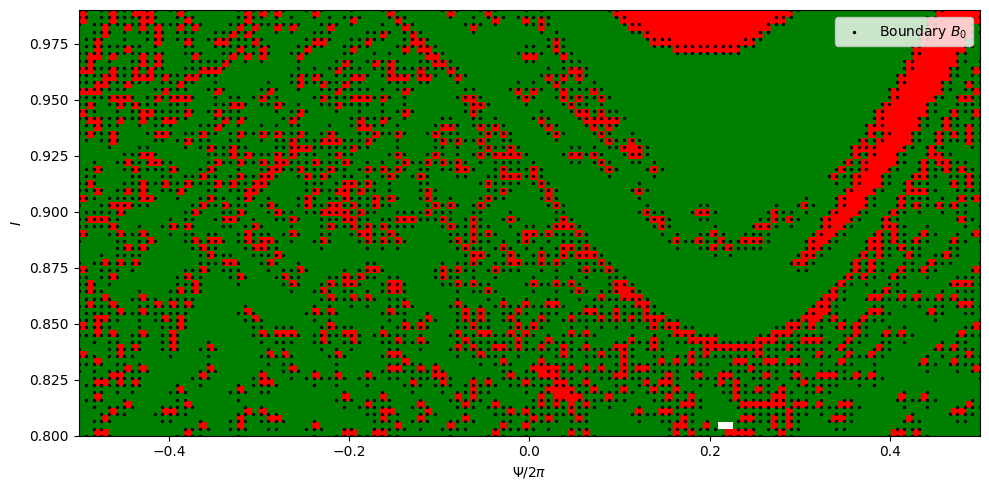

In [81]:
### Figure 2
plt.figure(
    figsize=(10, 5)
)


plt.imshow(
    basin,
    origin="lower",
    aspect="auto",
    extent=[
        PSI_NORM_MIN,
        PSI_NORM_MAX,
        I_EDGE_MIN,
        I_EDGE_MAX
    ],
    cmap=basin_cmap,
    vmin=0,
    vmax=2,
    interpolation="nearest"
)


plt.scatter(
    boundary_psi_norm,
    boundary_I,
    s=8,
    c="black",
    marker=".",
    label=r"Boundary $B_0$"
)


plt.xlabel(
    r"$\Psi/2\pi$"
)

plt.ylabel(
    r"$I$"
)


plt.legend()

plt.tight_layout()

plt.savefig(
    "figure2_deterministic_basin_B0.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

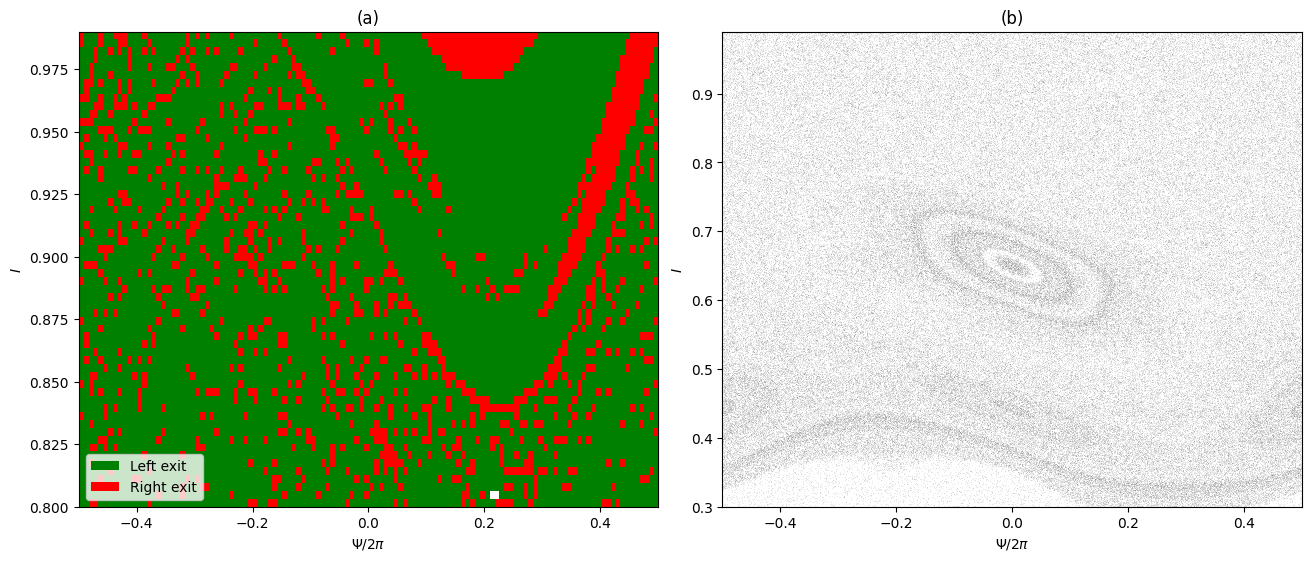

Figure 3 complete.
rho is not identified with Db.


In [82]:
### Figure 3

phi_fig3 = PHI_PRIMARY

rho_fig3 = SOUZA_RHO_CONTROL
P_fig3 = SOUZA_P_CONTROL


# Make historical Souza-noise result reproducible
set_numba_seed(
    SOUZA_NOISE_SEED
)


I_souza_fig3, psi_souza_fig3 = (
    generate_phase_space(
        phi=phi_fig3,
        N_steps=700,
        num_initial_I=25,
        num_initial_psi=25,
        I_min=0.30,
        I_max=1.00,
        psi_min=-np.pi,
        psi_max=np.pi,
        collision_model=1,
        collision_amplitude=rho_fig3,
        collision_probability=P_fig3,
        burn_in=50
    )
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5.5),
    constrained_layout=True
)


# ============================================================
# (a) Deterministic escape basin
# ============================================================

axes[0].imshow(
    basin,
    origin="lower",
    aspect="auto",
    extent=[
        PSI_NORM_MIN,
        PSI_NORM_MAX,
        I_EDGE_MIN,
        I_EDGE_MAX
    ],
    cmap=basin_cmap,
    vmin=0,
    vmax=2,
    interpolation="nearest"
)


axes[0].set_xlabel(
    r"$\Psi/2\pi$"
)

axes[0].set_ylabel(
    r"$I$"
)

axes[0].set_title("(a)", loc="center")


axes[0].legend(
    handles=[
        Patch(
            facecolor="green",
            label="Left exit"
        ),
        Patch(
            facecolor="red",
            label="Right exit"
        )
    ],
    loc="lower left"
)


# ============================================================
# (b) Existing Souza-noise result
# ============================================================

axes[1].scatter(
    psi_souza_fig3
    / (2.0 * np.pi),
    I_souza_fig3,
    s=0.14,
    alpha=0.35,
    c="dimgray",
    linewidths=0,
    rasterized=True
)


axes[1].set_xlim(
    -0.5,
    0.5
)

axes[1].set_ylim(
    0.30,
    0.99
)

axes[1].set_xlabel(
    r"$\Psi/2\pi$"
)

axes[1].set_ylabel(
    r"$I$"
)

axes[1].set_title("(b)", loc="center")

plt.savefig(
    "figure3_deterministic_vs_souza_noise.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


print(
    "Figure 3 complete."
)

print(
    "rho is not identified with Db."
)



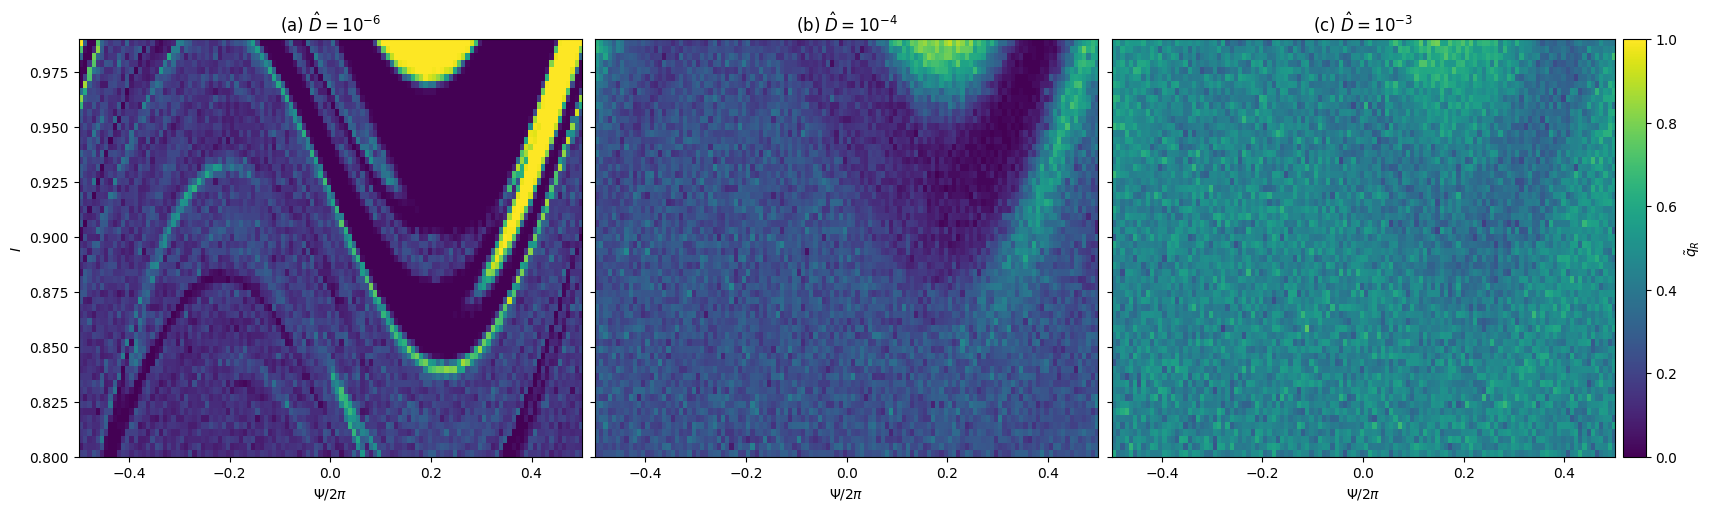

In [83]:
### Figure 4 - Right-exit committor

Db_figure_values = [
    1e-6,
    1e-4,
    1e-3
]

panel_labels = ["(a)", "(b)", "(c)"]

titles = {
    1e-6: r"$\hat{D}=10^{-6}$",
    1e-4: r"$\hat{D}=10^{-4}$",
    1e-3: r"$\hat{D}=10^{-3}$"
}


# ------------------------------------------------------------
# Create three plot panels + one dedicated colourbar column
# ------------------------------------------------------------

fig = plt.figure(
    figsize=(17, 5),
    constrained_layout=True
)

gs = fig.add_gridspec(
    1,
    4,
    width_ratios=[1, 1, 1, 0.045]
)

axes = []

ax0 = fig.add_subplot(gs[0, 0])
axes.append(ax0)

ax1 = fig.add_subplot(
    gs[0, 1],
    sharex=ax0,
    sharey=ax0
)
axes.append(ax1)

ax2 = fig.add_subplot(
    gs[0, 2],
    sharex=ax0,
    sharey=ax0
)
axes.append(ax2)

cax = fig.add_subplot(gs[0, 3])


# ------------------------------------------------------------
# Plot the three diffusion strengths
# ------------------------------------------------------------

for ax, Db_value, panel in zip(
    axes,
    Db_figure_values,
    panel_labels
):

    qeR_plot = np.ma.masked_invalid(
        scan_maps[float(Db_value)]["qeR"]
    )

    image = ax.imshow(
        qeR_plot,
        origin="lower",
        aspect="auto",
        extent=[
            PSI_NORM_MIN,
            PSI_NORM_MAX,
            I_EDGE_MIN,
            I_EDGE_MAX
        ],
        vmin=0.0,
        vmax=1.0,
        interpolation="nearest"
    )

    ax.set_title(
        f"{panel} " + titles[Db_value],
        loc="center"
    )

    ax.set_xlabel(
        r"$\Psi/2\pi$"
    )


# Only show the y-axis label on the first panel
axes[0].set_ylabel(
    r"$I$"
)

# Hide repeated y tick labels on panels (b) and (c)
for ax in axes[1:]:
    ax.tick_params(
        labelleft=False
    )


# ------------------------------------------------------------
# Dedicated colourbar
# ------------------------------------------------------------

colorbar = fig.colorbar(
    image,
    cax=cax
)

colorbar.set_label(
    r"$\tilde{q}_R$"
)


# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

plt.savefig(
    "figure4_right_exit_committor.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

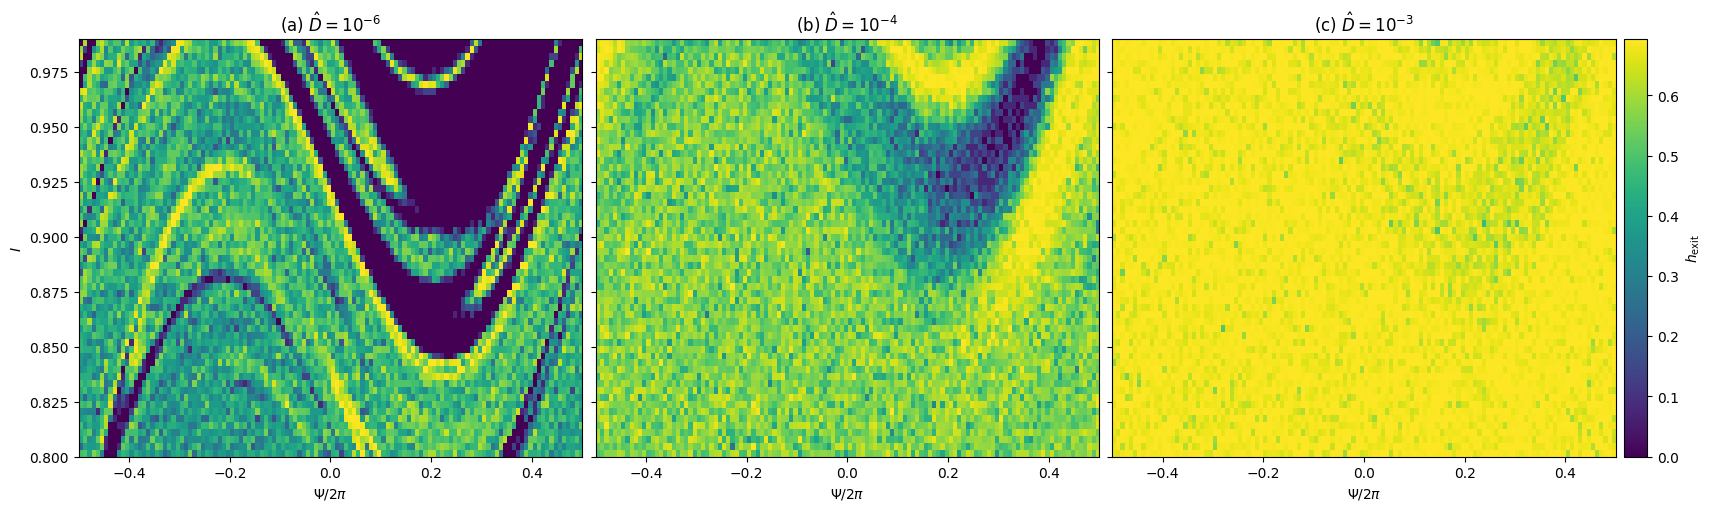

In [84]:
### Figure 5 - Exit entropy

Db_figure_values = [
    1e-6,
    1e-4,
    1e-3
]

panel_labels = ["(a)", "(b)", "(c)"]

titles = {
    1e-6: r"$\hat{D}=10^{-6}$",
    1e-4: r"$\hat{D}=10^{-4}$",
    1e-3: r"$\hat{D}=10^{-3}$"
}


# ------------------------------------------------------------
# Create three plot panels + one dedicated colourbar column
# ------------------------------------------------------------

fig = plt.figure(
    figsize=(17, 5),
    constrained_layout=True
)

gs = fig.add_gridspec(
    1,
    4,
    width_ratios=[1, 1, 1, 0.045]
)

axes = []

ax0 = fig.add_subplot(gs[0, 0])
axes.append(ax0)

ax1 = fig.add_subplot(
    gs[0, 1],
    sharex=ax0,
    sharey=ax0
)
axes.append(ax1)

ax2 = fig.add_subplot(
    gs[0, 2],
    sharex=ax0,
    sharey=ax0
)
axes.append(ax2)

cax = fig.add_subplot(gs[0, 3])


# ------------------------------------------------------------
# Plot the three diffusion strengths
# ------------------------------------------------------------

for ax, Db_value, panel in zip(
    axes,
    Db_figure_values,
    panel_labels
):

    entropy_plot = np.ma.masked_invalid(
        scan_maps[float(Db_value)]["entropy"]
    )

    image = ax.imshow(
        entropy_plot,
        origin="lower",
        aspect="auto",
        extent=[
            PSI_NORM_MIN,
            PSI_NORM_MAX,
            I_EDGE_MIN,
            I_EDGE_MAX
        ],
        vmin=0.0,
        vmax=np.log(2.0),
        interpolation="nearest"
    )

    ax.set_title(
        f"{panel} " + titles[Db_value],
        loc="center"
    )

    ax.set_xlabel(
        r"$\Psi/2\pi$"
    )


# Only show the y-axis label on the first panel
axes[0].set_ylabel(
    r"$I$"
)

# Hide repeated y tick labels on panels (b) and (c)
for ax in axes[1:]:
    ax.tick_params(
        labelleft=False
    )


# ------------------------------------------------------------
# Dedicated colourbar
# ------------------------------------------------------------

colorbar = fig.colorbar(
    image,
    cax=cax
)

colorbar.set_label(
    r"$h_{\mathrm{exit}}$"
)


# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

plt.savefig(
    "figure5_exit_entropy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

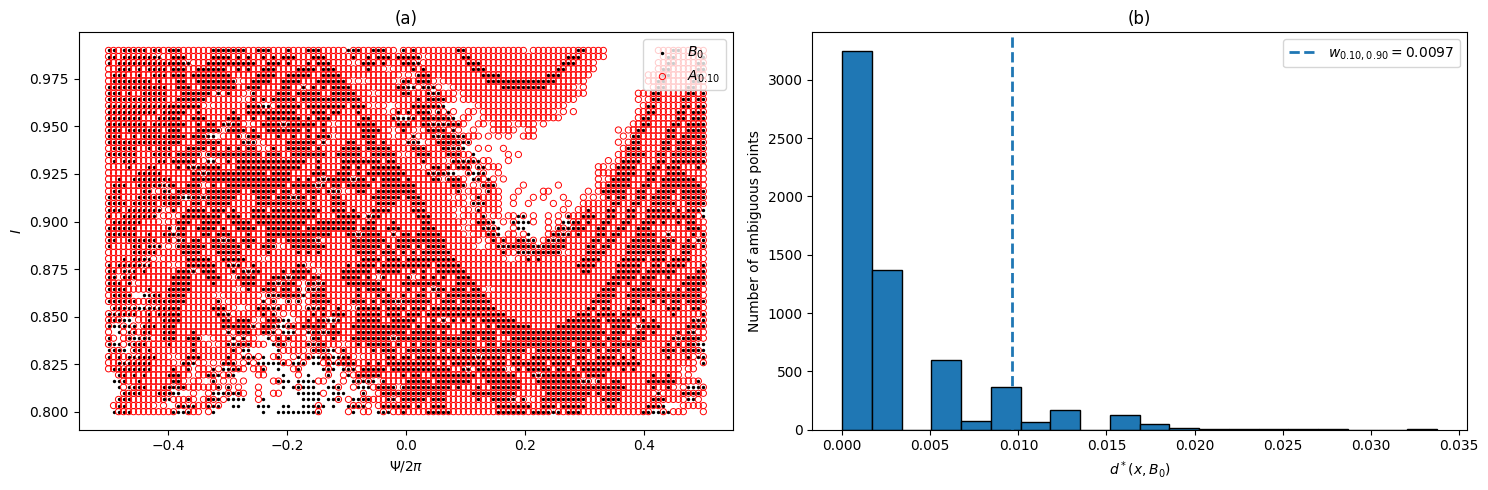

Figure 6 ambiguity width = 0.009661016949152557


In [85]:
### Figure 6

Db_fig6 = 1e-4

maps_fig6 = scan_maps[
    float(Db_fig6)
]


ambiguity_fig6 = (
    maps_fig6[
        "ambiguity_mask"
    ]
)


I_fig6 = maps_fig6[
    "I_grid"
]

psi_fig6 = maps_fig6[
    "psi_norm_grid"
]


ambiguous_distances_fig6 = (
    distance_to_boundary_grid[
        ambiguity_fig6
    ]
)


if (
    ambiguous_distances_fig6.size
    > 0
):

    width_fig6 = np.percentile(
        ambiguous_distances_fig6,
        90
    )

else:

    width_fig6 = np.nan


amb_i_fig6, amb_j_fig6 = (
    np.where(
        ambiguity_fig6
    )
)


amb_I_fig6 = I_fig6[
    amb_i_fig6
]

amb_psi_fig6 = psi_fig6[
    amb_j_fig6
]


fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 5)
)


# ============================================================
# Left: ambiguity set and deterministic boundary
# ============================================================

axes[0].scatter(
    boundary_psi_norm,
    boundary_I,
    s=8,
    c="black",
    marker=".",
    label=r"$B_0$"
)


axes[0].scatter(
    amb_psi_fig6,
    amb_I_fig6,
    s=20,
    facecolors="none",
    edgecolors="red",
    marker="o",
    linewidths=0.7,
    label=r"$A_{0.10}$"
)


axes[0].set_xlabel(
    r"$\Psi/2\pi$"
)

axes[0].set_ylabel(
    r"$I$"
)

axes[0].set_title("(a)", loc="center")


axes[0].legend()


# ============================================================
# Right: distances to B0
# ============================================================

axes[1].hist(
    ambiguous_distances_fig6,
    bins=20,
    edgecolor="black"
)


axes[1].axvline(
    width_fig6,
    linestyle="--",
    linewidth=2,
    label=(
        rf"$w_{{0.10,0.90}}"
        rf"={width_fig6:.4f}$"
    )
)


axes[1].set_xlabel(
    r"$d^*(x,B_0)$"
)

axes[1].set_ylabel(
    "Number of ambiguous points"
)

axes[1].set_title("(b)", loc="center")


axes[1].legend()


plt.tight_layout()

plt.savefig(
    "figure6_ambiguity_layer.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


print(
    "Figure 6 ambiguity width =",
    width_fig6
)

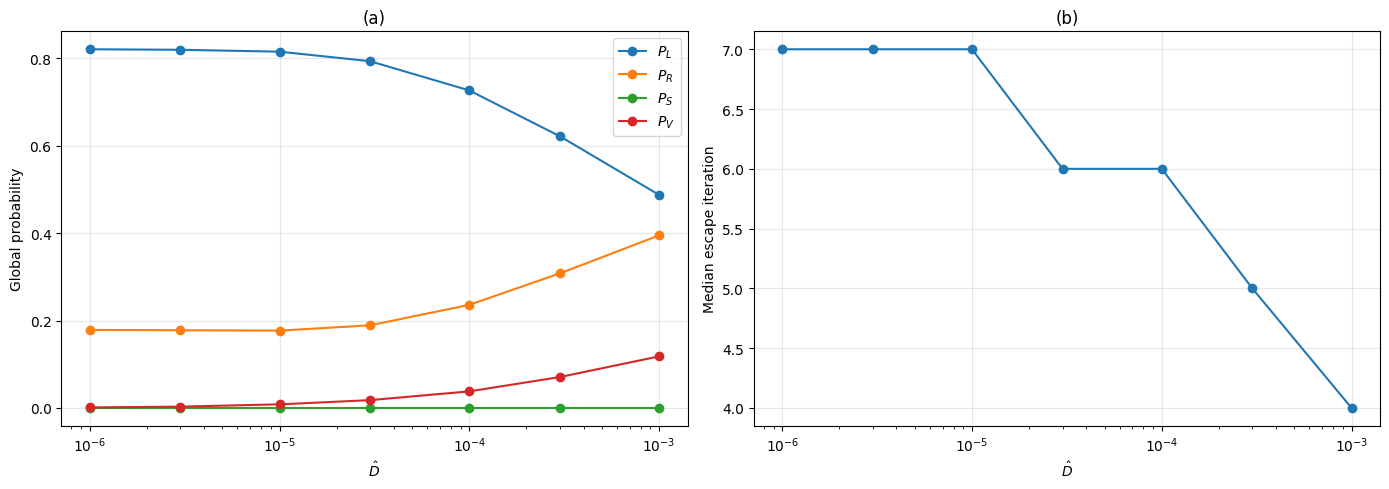

Db = 0 deterministic reference:
PL = 0.812
PR = 0.187
PS = 0.001
PV = 0.0
Median iteration = 7.0


In [86]:
### Figure 7

global_array = np.array(
    global_scan_results,
    dtype=np.float64
)

Db_global_plot = global_array[:, 0]
PL_global_plot = global_array[:, 1]
PR_global_plot = global_array[:, 2]
PS_global_plot = global_array[:, 3]
PV_global_plot = global_array[:, 4]
median_global_plot = global_array[:, 5]


# Logarithmic axes require Db > 0
nonzero_global = (
    Db_global_plot > 0.0
)


fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)


# ------------------------------------------------------------
# Global probabilities
# ------------------------------------------------------------

axes[0].semilogx(
    Db_global_plot[nonzero_global],
    PL_global_plot[nonzero_global],
    marker="o",
    label=r"$P_L$"
)

axes[0].semilogx(
    Db_global_plot[nonzero_global],
    PR_global_plot[nonzero_global],
    marker="o",
    label=r"$P_R$"
)

axes[0].semilogx(
    Db_global_plot[nonzero_global],
    PS_global_plot[nonzero_global],
    marker="o",
    label=r"$P_S$"
)

axes[0].semilogx(
    Db_global_plot[nonzero_global],
    PV_global_plot[nonzero_global],
    marker="o",
    label=r"$P_V$"
)

axes[0].set_xlabel(r"$\hat{D}$")
axes[0].set_ylabel("Global probability")
axes[0].set_title("(a)", loc="center")
axes[0].legend()
axes[0].grid(True, alpha=0.3)


# ------------------------------------------------------------
# Median escape iteration
# ------------------------------------------------------------

axes[1].semilogx(
    Db_global_plot[nonzero_global],
    median_global_plot[nonzero_global],
    marker="o"
)

axes[1].set_xlabel(r"$\hat{D}$")
axes[1].set_ylabel("Median escape iteration")
axes[1].set_title("(b)", loc="center")
axes[1].grid(True, alpha=0.3)


plt.tight_layout()
plt.savefig(
    "figure7_global_stochastic_scan.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


# ------------------------------------------------------------
# Report deterministic Db = 0 reference separately
# ------------------------------------------------------------

zero_index = np.where(
    Db_global_plot == 0.0
)[0]

if zero_index.size > 0:

    z = zero_index[0]

    print("Db = 0 deterministic reference:")
    print("PL =", PL_global_plot[z])
    print("PR =", PR_global_plot[z])
    print("PS =", PS_global_plot[z])
    print("PV =", PV_global_plot[z])
    print(
        "Median iteration =",
        median_global_plot[z]
    )

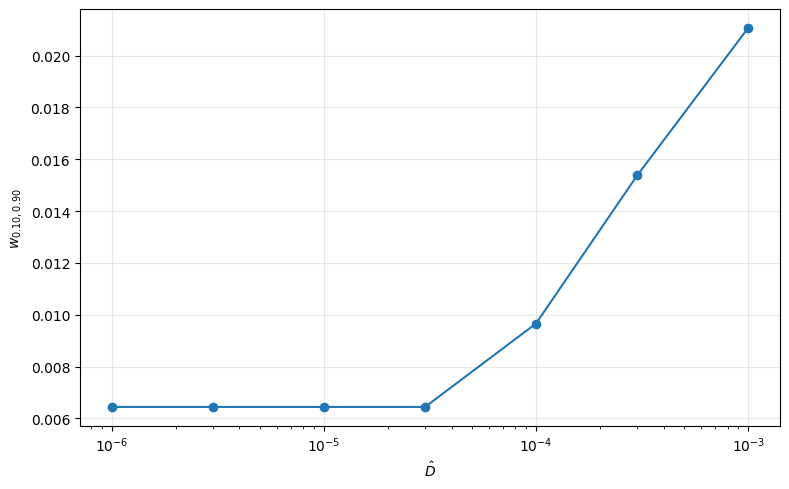

In [87]:
### Figure 8

scan_array = np.array(
    scan_results,
    dtype=np.float64
)

Db_width_plot = scan_array[:, 0]
N_amb_width_plot = scan_array[:, 1]
width_plot = scan_array[:, 3]


# Use only:
#   Db > 0
#   finite width values
#   non-empty ambiguity sets
valid_width = (
    (Db_width_plot > 0.0)
    & np.isfinite(width_plot)
    & (
    N_amb_width_plot
    >= MIN_AMBIGUOUS_SAMPLES
)
)


plt.figure(figsize=(8, 5))

plt.semilogx(
    Db_width_plot[valid_width],
    width_plot[valid_width],
    marker="o"
)

plt.xlabel(r"$\hat{D}$")

plt.ylabel(
    r"$w_{0.10,0.90}$"
)


plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()
plt.savefig(
    "figure8_ambiguity_width.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

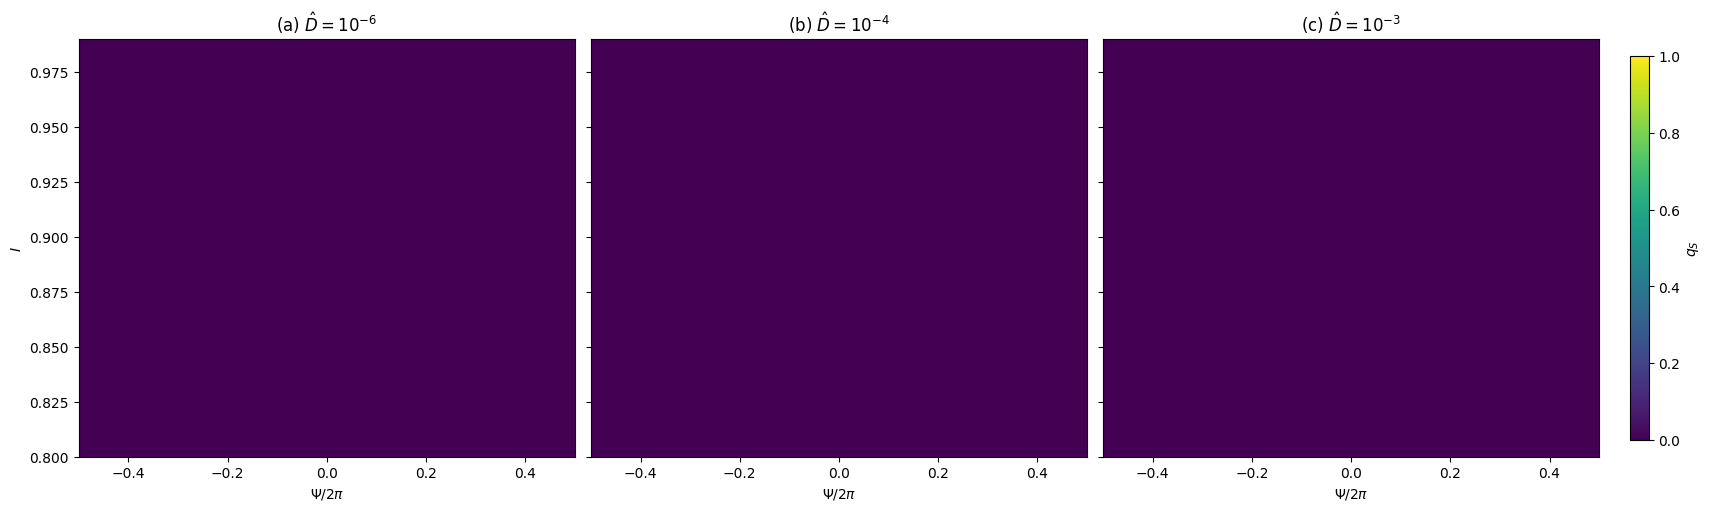

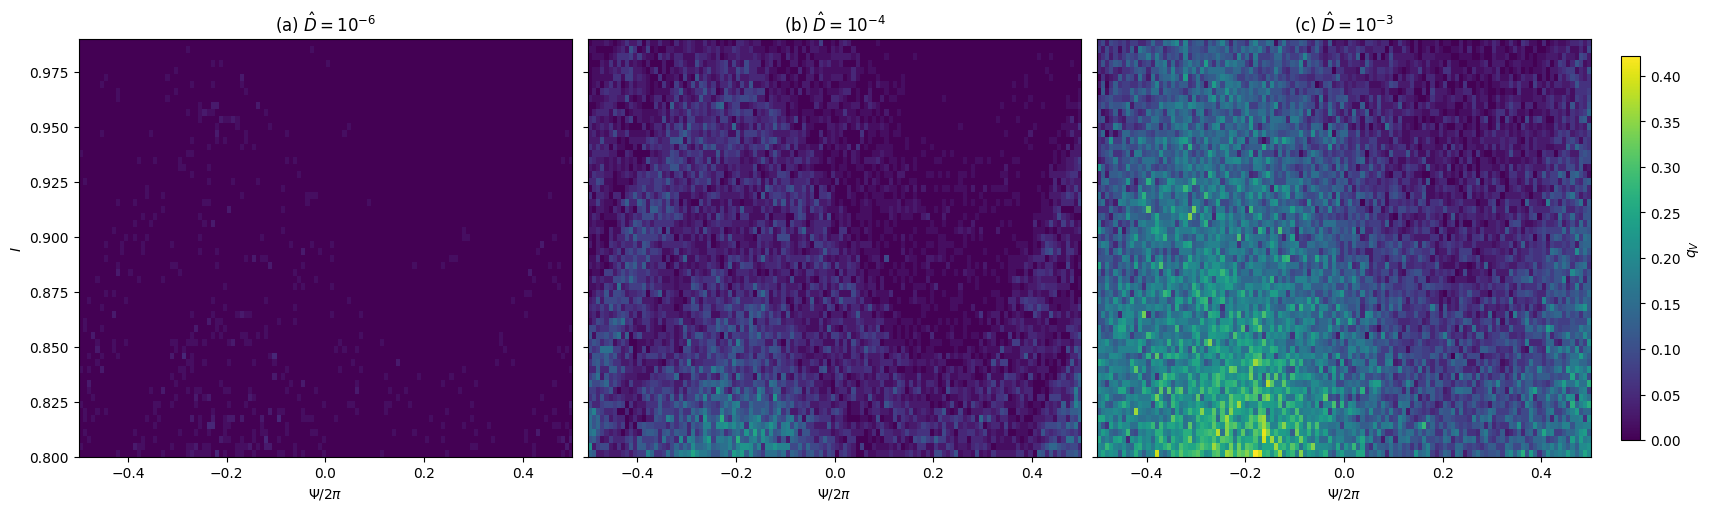

Appendix qS and qV diagnostic figures complete.
Maximum qV used for common Appendix A2 colour scale: 0.421875


In [88]:
### Appendix Diagnostics - Local qS and qV Maps

Db_diagnostic_values = [
    1e-6,
    1e-4,
    1e-3
]

panel_labels = ["(a)", "(b)", "(c)"]

titles = {
    1e-6: r"$\hat{D}=10^{-6}$",
    1e-4: r"$\hat{D}=10^{-4}$",
    1e-3: r"$\hat{D}=10^{-3}$"
}


# ============================================================
# Appendix figure9_local_survival_qS.png
# ============================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(17, 5),
    sharex=True,
    sharey=True,
    constrained_layout=True
)

for ax, Db_value, panel in zip(
    axes,
    Db_diagnostic_values,
    panel_labels
):

    qS_plot = scan_maps[
        float(Db_value)
    ]["qS"]

    image = ax.imshow(
        qS_plot,
        origin="lower",
        aspect="auto",
        extent=[
            PSI_NORM_MIN,
            PSI_NORM_MAX,
            I_EDGE_MIN,
            I_EDGE_MAX
        ],
        vmin=0.0,
        vmax=1.0,
        interpolation="nearest"
    )

    ax.set_title(
        f"{panel} " + titles[Db_value],
        loc="center"
    )

    ax.set_xlabel(
        r"$\Psi/2\pi$"
    )

axes[0].set_ylabel(
    r"$I$"
)

colorbar = fig.colorbar(
    image,
    ax=axes,
    shrink=0.92,
    pad=0.02
)

colorbar.set_label(
    r"$q_S$"
)

plt.savefig(
    "figure9_local_survival_qS.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# Appendix figure10_local_validity_qV.png
# ============================================================

qV_diagnostic_max = max(
    np.max(
        scan_maps[
            float(Db_value)
        ]["qV"]
    )
    for Db_value in Db_diagnostic_values
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(17, 5),
    sharex=True,
    sharey=True,
    constrained_layout=True
)

for ax, Db_value, panel in zip(
    axes,
    Db_diagnostic_values,
    panel_labels
):

    qV_plot = scan_maps[
        float(Db_value)
    ]["qV"]

    image = ax.imshow(
        qV_plot,
        origin="lower",
        aspect="auto",
        extent=[
            PSI_NORM_MIN,
            PSI_NORM_MAX,
            I_EDGE_MIN,
            I_EDGE_MAX
        ],
        vmin=0.0,
        vmax=qV_diagnostic_max,
        interpolation="nearest"
    )

    ax.set_title(
        f"{panel} " + titles[Db_value],
        loc="center"
    )

    ax.set_xlabel(
        r"$\Psi/2\pi$"
    )

axes[0].set_ylabel(
    r"$I$"
)

colorbar = fig.colorbar(
    image,
    ax=axes,
    shrink=0.92,
    pad=0.02
)

colorbar.set_label(
    r"$q_V$"
)

plt.savefig(
    "figure10_local_validity_qV.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


print(
    "Appendix qS and qV diagnostic figures complete."
)

print(
    "Maximum qV used for common Appendix A2 colour scale:",
    qV_diagnostic_max
)

In [89]:
### Save numerical outputs
# ------------------------------------------------------------
# 1. Db scan summary
# ------------------------------------------------------------

scan_df = pd.DataFrame(
    scan_results,
    columns=[
        "Db",
        "N_ambiguous",
        "ambiguous_fraction",
        "width_0p10_0p90",
        "max_qS",
        "max_qV",
        "max_probability_error"
    ]
)

scan_df.to_csv(
    "db_scan_results.csv",
    index=False
)


# ------------------------------------------------------------
# 2. Global scan summary
# ------------------------------------------------------------

global_scan_df = pd.DataFrame(
    global_scan_results,
    columns=[
        "Db",
        "PL",
        "PR",
        "PS",
        "PV",
        "median_escape_iteration"
    ]
)

global_scan_df.to_csv(
    "global_db_scan_results.csv",
    index=False
)


# ------------------------------------------------------------
# 3. Nc convergence results
# ------------------------------------------------------------

Nc_df = pd.DataFrame(
    Nc_convergence_results,
    columns=[
        "Nc",
        "PL",
        "PR",
        "PS",
        "PV",
        "median_escape_iteration",
        "probability_sum"
    ]
)

Nc_df.to_csv(
    "Nc_convergence_results.csv",
    index=False
)


# ------------------------------------------------------------
# 4. Store complete stochastic maps
# ------------------------------------------------------------

map_output = {}
# ------------------------------------------------------------
# Store Figure 3 Souza-noise control data
# ------------------------------------------------------------

map_output["I_souza_fig3"] = I_souza_fig3
map_output["psi_souza_fig3"] = psi_souza_fig3


for Db, maps in scan_maps.items():

    tag = (
        f"{Db:.0e}"
        .replace("-", "m")
        .replace("+", "p")
    )

    for key in [
        "qL",
        "qR",
        "qS",
        "qV",
        "escaped_fraction",
        "qeL",
        "qeR",
        "entropy",
        "ambiguity_mask"
    ]:

        map_output[
            f"{key}_Db_{tag}"
        ] = maps[key]


map_output[
    "I_grid"
] = I_grid

map_output[
    "psi_norm_grid"
] = psi_norm_grid

map_output[
    "deterministic_basin"
] = basin

map_output[
    "boundary_mask"
] = boundary_mask

map_output[
    "distance_to_boundary"
] = distance_to_boundary_grid


np.savez_compressed(
    "stochastic_map_outputs.npz",
    **map_output
)


print(
    "Numerical output files saved:"
)

print(
    "  db_scan_results.csv"
)

print(
    "  global_db_scan_results.csv"
)

print(
    "  Nc_convergence_results.csv"
)

print(
    "  stochastic_map_outputs.npz"
)

Numerical output files saved:
  db_scan_results.csv
  global_db_scan_results.csv
  Nc_convergence_results.csv
  stochastic_map_outputs.npz


In [90]:
### Check files

files_to_check = [
    "db_scan_results.csv",
    "global_db_scan_results.csv",
    "Nc_convergence_results.csv",
    "stochastic_map_outputs.npz"
]

for filename in files_to_check:
    if os.path.exists(filename):
        size_kb = os.path.getsize(filename) / 1024
        print(f"FOUND: {filename} ({size_kb:.2f} KB)")
    else:
        print(f"MISSING: {filename}")

FOUND: db_scan_results.csv (0.54 KB)
FOUND: global_db_scan_results.csv (0.39 KB)
FOUND: Nc_convergence_results.csv (0.29 KB)
FOUND: stochastic_map_outputs.npz (6425.26 KB)
